# Toda Oszillator

In [1]:
#imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.integrate import trapezoid

## Kapazität der Diode
Die Resonanzfrequenz im Serienschwingkreis ist $\omega_0=1/\sqrt{LC}$. Wenn wir also die Resonanzfrequenz messen, können wir die Kapazität bestimmen.

In [2]:
# Messwertetabelle (aus dem eLab) 
reso_freq = {
    # Uoff in V : f in Hz
    -0.70 : 73.1e3,
    -0.63 : 72.3e3,
    -0.56 : 71.6e3,
    -0.49 : 70.7e3,
    -0.42 : 69.7e3,
    -0.35 : 68.8e3,
    -0.28 : 67.6e3,
    -0.21 : 66.5e3,
    -0.14 : 65.1e3,
    -0.07 : 63.6e3,
     0.00 : 61.8e3,
     0.03 : 61.0e3,
     0.06 : 60.0e3,
     0.09 : 59.0e3,
     0.12 : 57.9e3,
     0.15 : 56.5e3,
     0.18 : 54.8e3,
     0.21 : 52.4e3,
     0.24 : 48.2e3,
     0.27 : 40.1e3,
     0.30 : 24.9e3
}


C0 = 100e-12 # 100 pF

def Kapazität(Frequenz: np.ndarray) -> np.ndarray:
    L = 64e-3 # 64 mH
    C = []
    for freq in Frequenz:
        C.append(1/(L*freq*freq*4*np.pi*np.pi)) # 2 pi f = w
    return np.array(C) # Kapazität in F

[  23.96572469 -313.31849747   74.28190109] 2.1105850095182177e-05


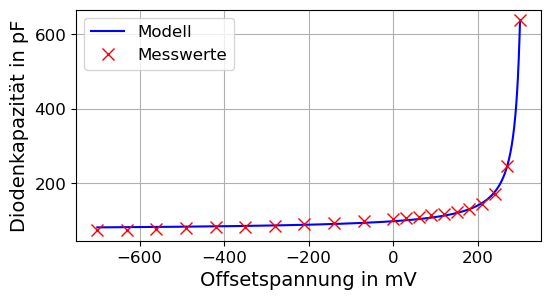

In [17]:
# Messwertelisten
Spannung = np.array(list(reso_freq))*1e3
Frequenz = np.array(list(reso_freq.values()))
Kapa = Kapazität(Frequenz)*1e12

# Fitten
def residuen_skript(coeff, U, C):
    c0, Us, o = coeff
    return C - (c0*Us)/(Us + U) - o

guess_skript = [100, -500, 50]

fit_skript = least_squares(residuen_skript, guess_skript, args=(Spannung, Kapa), method='lm')

Parameter_skript = fit_skript.x

print(Parameter_skript, fit_skript.optimality)
c0, Us, o = Parameter_skript

kontinuierlich = np.arange(min(Spannung), max(Spannung)+1)
modell_skript = (c0*Us)/(Us + kontinuierlich) + o

# plotting
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(kontinuierlich, modell_skript, "b", label="Modell")
ax.plot(Spannung, Kapa, "xr", label="Messwerte", ms=9)
ax.tick_params(axis="both", labelsize=12)
ax.set_xlabel("Offsetspannung in mV", fontsize=14)
ax.set_ylabel("Diodenkapazität in pF", fontsize=14)
ax.grid()
ax.legend(fontsize=12)
plt.show()

[ 9.70289973e+01  2.83657543e+02 -1.55437931e+05] 223.43861551966256


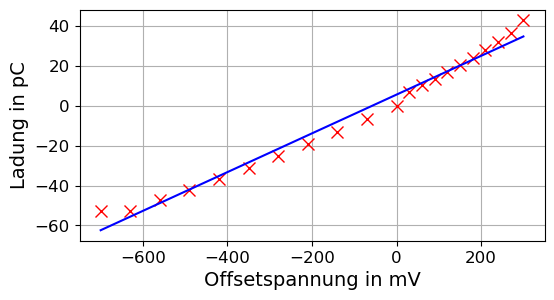

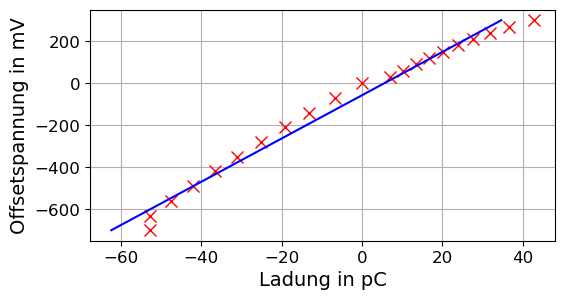

In [16]:
# erste Integration
Spannung = np.array(list(reso_freq))
Kapa = Kapazität(Frequenz)*1e12

Ladung = []

for i in range(len(Spannung)):
    Ladung.append(trapezoid(Kapa[:i], Spannung[:i]))

Ladung = np.array(Ladung)-Ladung[10]

# Fitten
def residuen_ladung(coeff, Q, U):
    c0, Us, o = coeff
    return Q - ((c0*Us)*np.log(Us+U)+o)

guess_ladung = [100, 300, 0]

fit_ladung = least_squares(residuen_ladung, guess_ladung, args=(Ladung, Spannung), method='lm')
Parameter_ladung = fit_ladung.x

print(Parameter_ladung, fit_ladung.optimality)
c0, Us, o = Parameter_ladung

kontinuierlich = np.arange(min(Spannung), max(Spannung)+1)
modell_ladung = (c0*Us)*np.log(Us+kontinuierlich)+o


# ax1
fig, ax1 = plt.subplots(figsize=(6,3))
ax1.plot(Spannung*1e3, Ladung, "xr", ms=9)
ax1.plot(kontinuierlich*1e3, modell_ladung, "b")
ax1.grid()
ax1.tick_params(axis="both", labelsize=12)
ax1.set_xlabel("Offsetspannung in mV", fontsize=14)
ax1.set_ylabel("Ladung in pC", fontsize=14)
# ax2
fig, ax2 = plt.subplots(figsize=(6,3))
ax2.plot(Ladung, Spannung*1e3, "xr", ms=9)
ax2.plot(modell_ladung, kontinuierlich*1e3, "b")
ax2.grid()
ax2.tick_params(axis="both", labelsize=12)
ax2.set_ylabel("Offsetspannung in mV", fontsize=14)
ax2.set_xlabel("Ladung in pC", fontsize=14)
plt.show()

[-3.18206666e+05  1.14385684e+00 -3.63987240e+05] 30092.278992821928
[7.49879767e+02 3.44787609e-03 2.67372994e+00 7.49353773e+02] 13.788667386550514


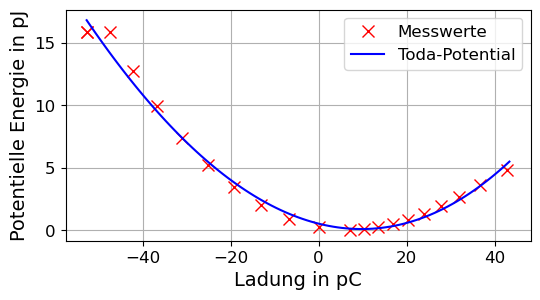

In [15]:
# zweite Integration
Spannung = np.array(list(reso_freq)) # V
Kapa = Kapazität(Frequenz) # pF
V = []

for i in range(len(Spannung)):
    V.append(trapezoid(Spannung[:i], Ladung[:i]))

V = np.array(V)-min(V) # pJ

# Fitten
def residuen_potential(coeff, Q, V):
    c0, Us, o = coeff
    return V - ((c0*Us)*np.exp(Q/c0/Us)-Us*Q-o)

def res_toda(coeff, Q, V):
    a, b, c, d = coeff
    return V - ( a*np.exp(b*Q)-c*Q-d )

guess_potential = [100, 300, 0]
guess_toda = [1, 1, 1, 1]

fit_potential = least_squares(residuen_potential, guess_potential, args=(Ladung, V), method='lm')
fit_toda = least_squares(res_toda, guess_toda, args=(Ladung, V), method="lm")
Parameter_potential = fit_potential.x
Para_Toda = fit_toda.x

print(Parameter_potential, fit_potential.optimality)
print(Para_Toda, fit_toda.optimality)
c0, Us, o = Parameter_potential
a, b, c, d = Para_Toda

kont_lad = np.arange(min(Ladung), max(Ladung)+1)
modell_potential = ((c0*Us)*np.exp(kont_lad/c0/Us)-Us*kont_lad-o)
toda = a*np.exp(b*kont_lad)-c*kont_lad-d

# plotten
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(Ladung, V, "xr", label="Messwerte", ms=9)
#ax.plot(kont_lad, modell_potential, "b")
ax.plot(kont_lad, toda, "b", label="Toda-Potential")
ax.grid()
ax.tick_params(axis="both", labelsize=12)
ax.set_xlabel("Ladung in pC", fontsize=14)
ax.set_ylabel("Potentielle Energie in pJ", fontsize=14)
ax.legend(fontsize=12)
plt.show()

## 5 Intermittenz

5.2 Nachweis von Intermittenz durch eine Zeitreihe

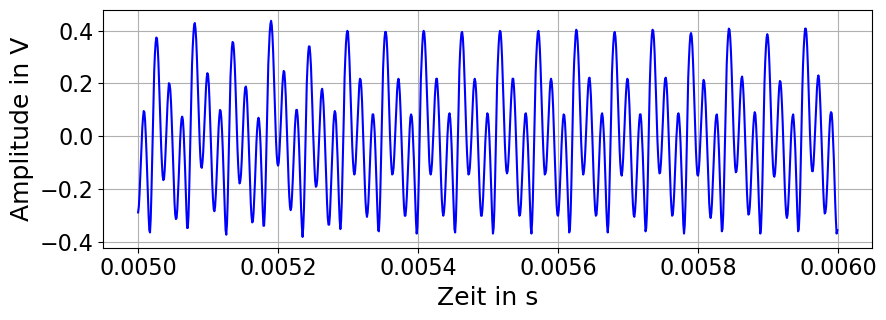

In [6]:
intm = np.loadtxt('../Messdaten/03112025_Toda_Oszillator/echte_intermittenz_nach_6_12V263.dat', delimiter=' ')
fig, ax = plt.subplots()
fig.set_size_inches(9, 3.3, forward=True)
ax.plot(intm[5000:6000,0], intm[5000:6000,2], "-b")
ax.grid()
ax.tick_params(axis="both", labelsize=16)
ax.set_xlabel("Zeit in s", fontsize=18)
ax.set_ylabel("Amplitude in V", fontsize=18)
fig.tight_layout()
plt.show()

## 7 Spektralanalyse
7.2. Spektren zu den Zuständen

Periode 1: 

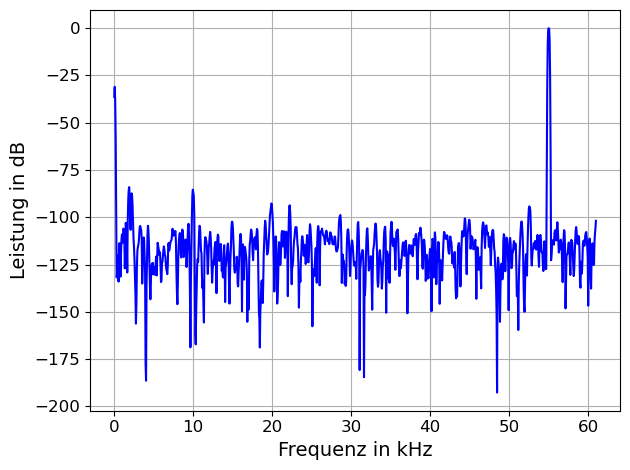

In [7]:
spek1p = np.loadtxt('../Messdaten//04112025_Toda_Spektren_und_Takens/periode1_spektrum.aps', delimiter='\t', max_rows=1000)
freq = np.array(spek1p[:,0])

fig, ax = plt.subplots()
ax.plot(freq*1e-3, spek1p[:,1], "-b")
ax.grid()
ax.tick_params(axis="both", labelsize=12)
ax.set_xlabel("Frequenz in kHz", fontsize=14)
ax.set_ylabel("Leistung in dB", fontsize=14)
#plt.title("Leistungsspektrum")
fig.tight_layout()
plt.show()

Periode 2: 

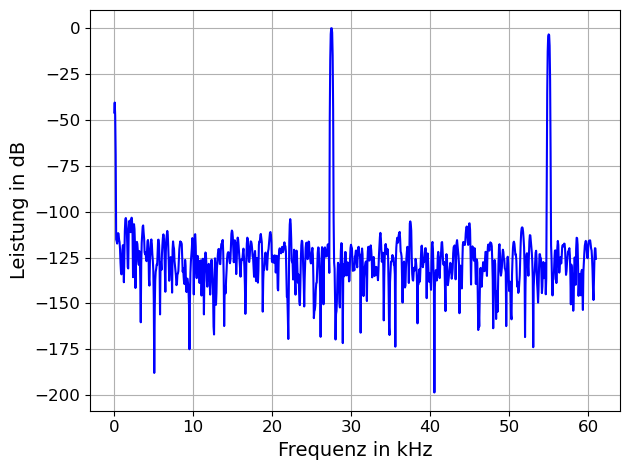

In [8]:
spek2p = np.loadtxt('../Messdaten//04112025_Toda_Spektren_und_Takens/periode2_spektrum.aps', delimiter='\t', max_rows=1000)
freq = np.array(spek2p[:,0])

fig, ax = plt.subplots()
ax.plot(freq*1e-3, spek2p[:,1], "-b")
ax.grid()
ax.tick_params(axis="both", labelsize=12)
ax.set_xlabel("Frequenz in kHz", fontsize=14)
ax.set_ylabel("Leistung in dB", fontsize=14)
#plt.title("Leistungsspektrum")
fig.tight_layout()
plt.show()

Periode 4

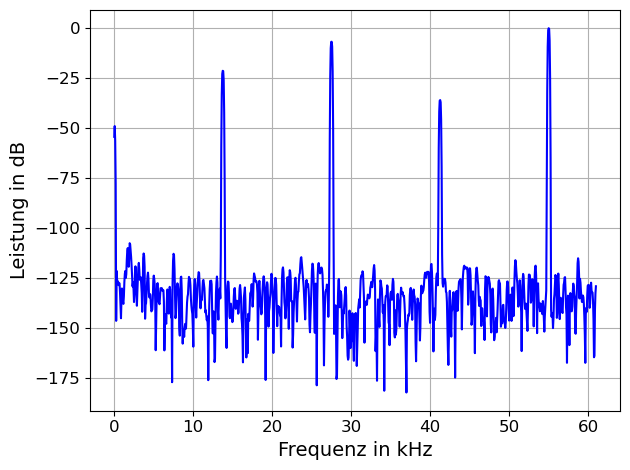

In [9]:
spek4p = np.loadtxt('../Messdaten//04112025_Toda_Spektren_und_Takens/periode4_spektrum.aps', delimiter='\t', max_rows=1000)
fig, ax = plt.subplots()
ax.plot(spek4p[:,0]*1e-3, spek4p[:,1], "-b")
ax.grid()
ax.tick_params(axis="both", labelsize=12)
ax.set_xlabel("Frequenz in kHz", fontsize=14)
ax.set_ylabel("Leistung in dB", fontsize=14)
fig.tight_layout()
plt.show()

Chaos:

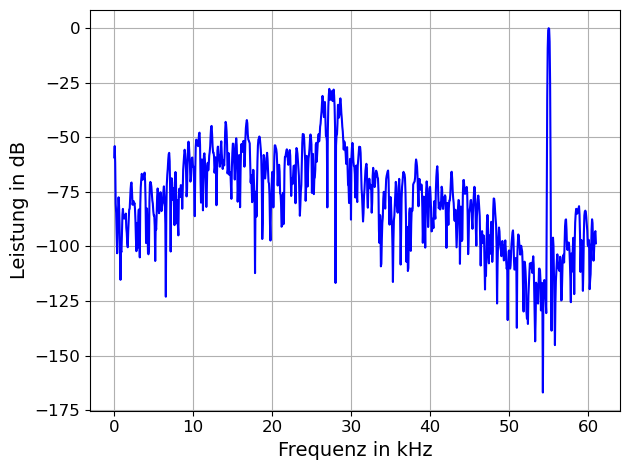

In [10]:
spekc = np.loadtxt('../Messdaten//04112025_Toda_Spektren_und_Takens/chaos_zw_4_3.aps', delimiter='\t', max_rows=1000)
fig, ax = plt.subplots()
ax.plot(spekc[:,0]*1e-3, spekc[:,1], "-b")
ax.grid()
ax.tick_params(axis="both", labelsize=12)
ax.set_xlabel("Frequenz in kHz", fontsize=14)
ax.set_ylabel("Leistung in dB", fontsize=14)
fig.tight_layout()
plt.show()

Periode 3:

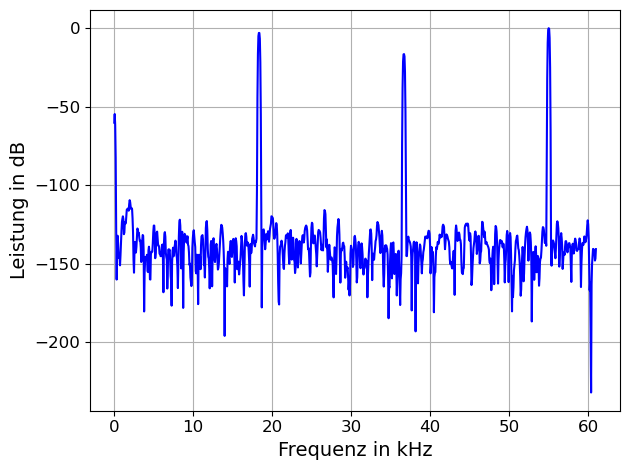

In [11]:
spek3p = np.loadtxt('../Messdaten//04112025_Toda_Spektren_und_Takens/periode3_spektrum.aps', delimiter='\t', max_rows=1000)
fig, ax = plt.subplots()
ax.plot(spek3p[:,0]*1e-3, spek3p[:,1], "-b")
ax.grid()
ax.tick_params(axis="both", labelsize=12)
ax.set_xlabel("Frequenz in kHz", fontsize=14)
ax.set_ylabel("Leistung in dB", fontsize=14)
fig.tight_layout()
plt.show()

Periode 6: 

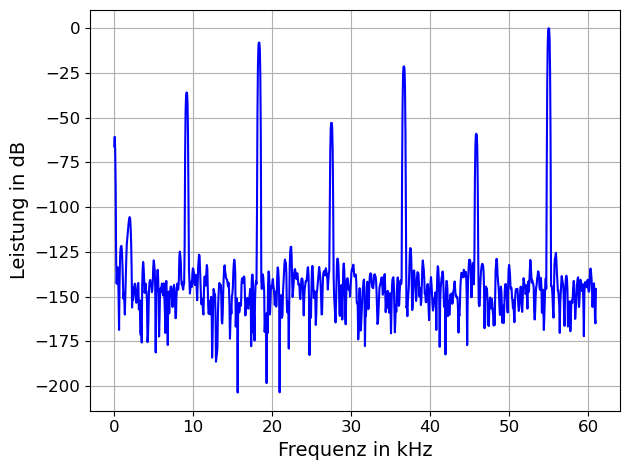

In [12]:
spek6p = np.loadtxt('../Messdaten//04112025_Toda_Spektren_und_Takens/periode6_spektrum.aps', delimiter='\t', max_rows=1000)
fig, ax = plt.subplots()
ax.plot(spek6p[:,0]*1e-3, spek6p[:,1], "-b")
ax.grid()
ax.tick_params(axis="both", labelsize=12)
ax.set_xlabel("Frequenz in kHz", fontsize=14)
ax.set_ylabel("Leistung in dB", fontsize=14)
fig.tight_layout()
plt.show()

Intermittenz nach 6:

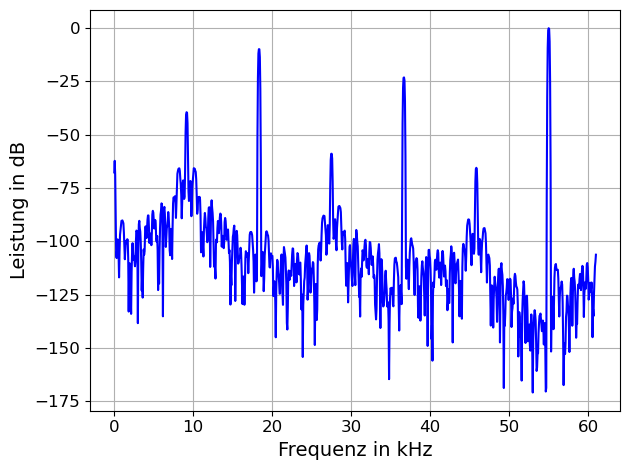

In [13]:
speki = np.loadtxt('../Messdaten//04112025_Toda_Spektren_und_Takens/intermittenz_nach_6.aps', delimiter='\t', max_rows=1000)
fig, ax = plt.subplots()
ax.plot(speki[:,0]*1e-3, speki[:,1], "-b")
ax.grid()
ax.tick_params(axis="both", labelsize=12)
ax.set_xlabel("Frequenz in kHz", fontsize=14)
ax.set_ylabel("Leistung in dB", fontsize=14)
fig.tight_layout()
plt.show()